In [3]:
import pandas as pd
raw = pd.read_csv("/Users/ethan/Documents/GitHub/ExPsyLing/experiments/masked_prime/data/combined_data.csv")

In [4]:
#raw.head(50)

In [5]:
#list(raw)

In [6]:
raw['response'].unique()

array([nan, 'n', 'm'], dtype=object)

In [7]:
# make a list of the columns we want
cols = ['participant_id', 'sender', 'duration', 'prime', 'target', 'condition', 'soa_condition', 'congruence', 'correct', 'response', 'correct_response']

In [8]:
df = raw[cols]

In [9]:
df = df[df['sender'] == 'target']

In [10]:
df

,participant_id,sender,duration,prime,target,condition,soa_condition,congruence,correct,response,correct_response
13,51,target,843.38,snjghf,SHEEP,practice,practice,practice,True,n,n
19,51,target,593.04,iweonf,BOAT,practice,practice,practice,True,m,m
25,51,target,559.18,nvoiuh,HOUSE,practice,practice,practice,True,m,m
31,51,target,653.76,abjdhjs,HORSE,practice,practice,practice,True,n,n
40,51,target,520.14,roof,PIANO,Inc_Synth_Synth,long,incongruent,True,m,m
...,...,...,...,...,...,...,...,...,...,...,...
15606,69,target,699.20,belt,BELT,Con_Synth,short,congruent,True,m,m
15612,69,target,580.20,daisy,DAISY,Con_Nat,short,congruent,True,n,n
15618,69,target,577.90,peach,SHED,Inc_Nat_Synth,short,incongruent,True,m,m
15624,69,target,661.10,rake,HUSKY,Inc_Synth_Nat,short,incongruent,True,n,n


In [19]:
df = raw[cols]
df = df[df['sender'] == 'target']
df = df[df['condition'] != 'practice']
df = df.drop(columns = ['sender'])

In [20]:
df

,participant_id,duration,prime,target,condition,soa_condition,congruence,correct,response,correct_response
40,51,520.14,roof,PIANO,Inc_Synth_Synth,long,incongruent,True,m,m
47,51,640.66,sheep,BULL,Inc_Nat_Nat,long,incongruent,False,n,m
54,51,597.74,fort,GOAT,Inc_Synth_Nat,long,incongruent,True,n,n
61,51,495.68,pear,PEAR,Con_Nat,long,congruent,True,n,n
68,51,556.86,olive,MOTOR,Inc_Nat_Synth,long,incongruent,True,m,m
...,...,...,...,...,...,...,...,...,...,...
15606,69,699.20,belt,BELT,Con_Synth,short,congruent,True,m,m
15612,69,580.20,daisy,DAISY,Con_Nat,short,congruent,True,n,n
15618,69,577.90,peach,SHED,Inc_Nat_Synth,short,incongruent,True,m,m
15624,69,661.10,rake,HUSKY,Inc_Synth_Nat,short,incongruent,True,n,n


In [21]:



df.loc[df['target'] == 'BULL', 'correct_response'] = 'n'



In [22]:
df

,participant_id,duration,prime,target,condition,soa_condition,congruence,correct,response,correct_response
40,51,520.14,roof,PIANO,Inc_Synth_Synth,long,incongruent,True,m,m
47,51,640.66,sheep,BULL,Inc_Nat_Nat,long,incongruent,False,n,n
54,51,597.74,fort,GOAT,Inc_Synth_Nat,long,incongruent,True,n,n
61,51,495.68,pear,PEAR,Con_Nat,long,congruent,True,n,n
68,51,556.86,olive,MOTOR,Inc_Nat_Synth,long,incongruent,True,m,m
...,...,...,...,...,...,...,...,...,...,...
15606,69,699.20,belt,BELT,Con_Synth,short,congruent,True,m,m
15612,69,580.20,daisy,DAISY,Con_Nat,short,congruent,True,n,n
15618,69,577.90,peach,SHED,Inc_Nat_Synth,short,incongruent,True,m,m
15624,69,661.10,rake,HUSKY,Inc_Synth_Nat,short,incongruent,True,n,n


In [23]:
#df['accuracy'] = df['response'] == df['correct_response']

In [25]:
df

,participant_id,duration,prime,target,condition,soa_condition,congruence,correct,response,correct_response
40,51,520.14,roof,PIANO,Inc_Synth_Synth,long,incongruent,True,m,m
47,51,640.66,sheep,BULL,Inc_Nat_Nat,long,incongruent,False,n,n
54,51,597.74,fort,GOAT,Inc_Synth_Nat,long,incongruent,True,n,n
61,51,495.68,pear,PEAR,Con_Nat,long,congruent,True,n,n
68,51,556.86,olive,MOTOR,Inc_Nat_Synth,long,incongruent,True,m,m
...,...,...,...,...,...,...,...,...,...,...
15606,69,699.20,belt,BELT,Con_Synth,short,congruent,True,m,m
15612,69,580.20,daisy,DAISY,Con_Nat,short,congruent,True,n,n
15618,69,577.90,peach,SHED,Inc_Nat_Synth,short,incongruent,True,m,m
15624,69,661.10,rake,HUSKY,Inc_Synth_Nat,short,incongruent,True,n,n


In [ ]:
df_grouped = df.groupby(['participant_id', 'condition1', 'condition2'])['rt'].mean().reset_index()


In [34]:
df_grouped

participant_id    duration
soa_condition congruence                             
long          congruent              60.0  744.555895
              incongruent            60.0  763.398526
short         congruent              60.0  729.435193
              incongruent            60.0  788.049614

In [35]:
df_grouped = df_grouped.reset_index()
df_grouped

,soa_condition,congruence,participant_id,duration
0,long,congruent,60.0,744.555895
1,long,incongruent,60.0,763.398526
2,short,congruent,60.0,729.435193
3,short,incongruent,60.0,788.049614


In [36]:
import seaborn as sns

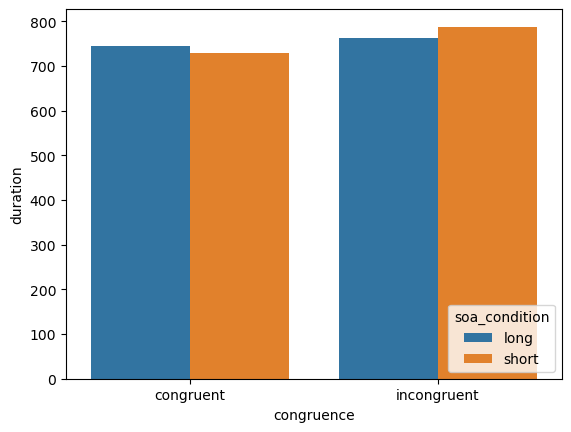

In [40]:
ax = sns.barplot(data = df_grouped, x = 'congruence', y = 'duration', hue = 'soa_condition')
sns.move_legend(ax, "lower right")